# TA02 — Calibração de Câmera

Este notebook é a camada de explicação, execução e visualização. A implementação reutilizável fica nos módulos Python em `calibration/`.


In [1]:
# ===== IMPORTS =====
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import numpy as np

from calibration.camera import (
    calibrate_camera,
    collect_calibration_points,
    create_object_points,
    create_undistortion_maps,
    undistort_image,
)
from calibration.config import CalibrationConfig, DatasetPaths
from calibration.image_io import list_images, load_image, pair_stereo_images
from calibration.reporting import (
    compare_with_ground_truth,
    create_output_archive,
    print_output_contents,
    print_summary,
    save_calibration_results,
    save_figure,
)
from calibration.synthetic import SyntheticConfig, generate_synthetic_images


In [2]:
# ===== CONFIGURAÇÕES =====
config = CalibrationConfig(
    board_corners=(9, 4),
    square_size_mm=90,
    device="android",
    colab=False,
    use_synthetic=True,
    alpha=1.0,
)
if not config.colab:
    config.root_dir = Path("data")
paths = DatasetPaths(config.root_dir, config.use_synthetic, config.device)

syn_config = SyntheticConfig(
    width = 1600,
    height = 1200,
    K = np.array([[1400.0, 0, 810.0],
                  [0, 1395.0, 590.0],
                  [0, 0, 1.0]]),
    distortion = np.array([-0.28, 0.12, 0.001, -0.0015, -0.02]),
    stereo_distance = 120.0,
    pixels_per_square = 60
)

print("Cantos internos:", config.board_corners)
print("Quadrado:", config.square_size_mm, "mm")
print("Lendo de:", paths.input)
print("Gravando em:", paths.output)


Cantos internos: (9, 4)
Quadrado: 90 mm
Lendo de: data/synthetic/input
Gravando em: data/synthetic/output


In [3]:
# ===== ENVIO DAS FOTOS (OPCIONAL) =====
# A implementação de upload fica em calibration.image_io.
# from calibration.image_io import upload_images
# if not config.use_synthetic:
#     upload_images(paths.calibration)
#     upload_images(paths.test)


## Gerador de Fotos Sintéticas

As imagens sintéticas validam a calibração usando uma matriz intrínseca e parâmetros de distorção conhecidos.


In [4]:
if config.use_synthetic:
    generate_synthetic_images(num_calib = 25, 
                              num_test = 3, 
                              num_stereo = 12, 
                              dataset_paths = paths, 
                              calibration_config = config, 
                              synthetic_config = syn_config)

25 de calibração, 3 de teste, 12 pares estéreoteste


In [5]:
# ===== LEITURA DAS IMAGENS =====
calibration_images = list_images(paths.calibration)
test_images = list_images(paths.test)
if not calibration_images:
    raise RuntimeError(f"Nenhuma imagem de calibração encontrada em {paths.calibration}")
image_size = load_image(calibration_images[0]).shape[:2][::-1]
print(len(calibration_images), "fotos de calibração |", len(test_images), "de teste")
print("resolução:", image_size)


25 fotos de calibração | 3 de teste
resolução: (1600, 1200)


In [6]:
# ===== DETECÇÃO DOS CANTOS =====
object_points = create_object_points(config.board_corners, config.square_size_mm)
obj_pts, img_pts, used_images, detected_image_size = collect_calibration_points(
    calibration_images,
    config.board_corners,
    config.square_size_mm,
)
print(f"tabuleiro detectado em {len(used_images)} de {len(calibration_images)} fotos")


tabuleiro detectado em 25 de 25 fotos


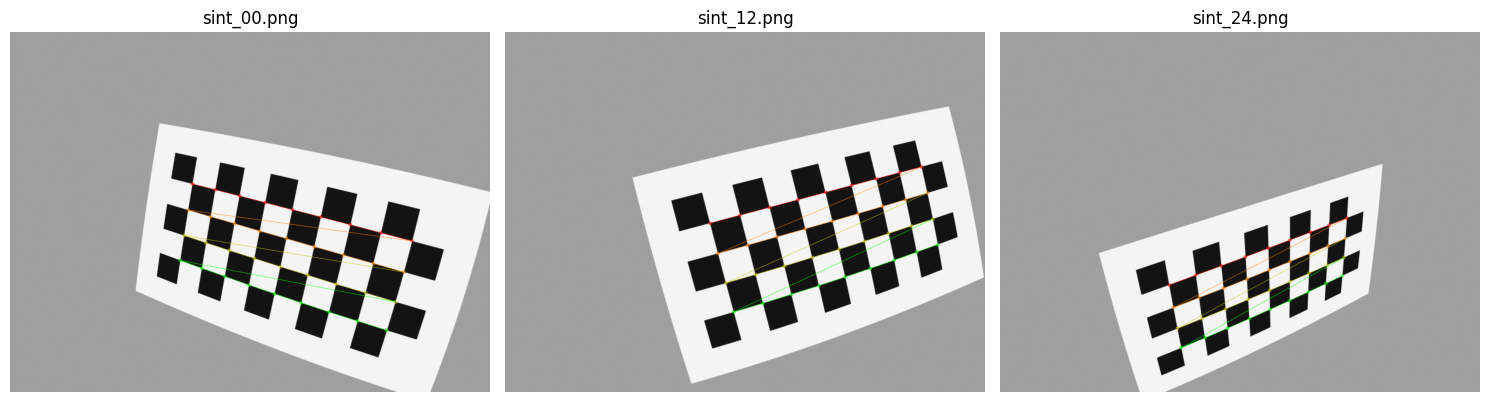

In [7]:
# ===== EXEMPLOS DA DETECÇÃO =====
fig, axes = plt.subplots(1, min(3, len(used_images)), figsize=(15, 4))
axes = np.atleast_1d(axes)
indices = np.linspace(0, len(used_images)-1, len(axes), dtype=int)
for axis, index in zip(axes, indices):
    image = load_image(used_images[index])
    drawn = cv2.drawChessboardCorners(image.copy(), config.board_corners, img_pts[index], True)
    axis.imshow(cv2.cvtColor(drawn, cv2.COLOR_BGR2RGB))
    axis.set_title(Path(used_images[index]).name)
    axis.axis("off")
plt.tight_layout()
save_figure("deteccao_cantos.png", paths.figures)
plt.show()


erro RMS de reprojeção: 0.0448 px
K =
 [[1.39987440e+03 0.00000000e+00 8.09956041e+02]
 [0.00000000e+00 1.39481433e+03 5.90126302e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
distorção [k1 k2 p1 p2 k3] = [-0.27881458  0.11381377  0.00097277 -0.0015391  -0.00842932]
campo de visão: 59.5° x 46.6°
erro médio por imagem: 0.0400 px


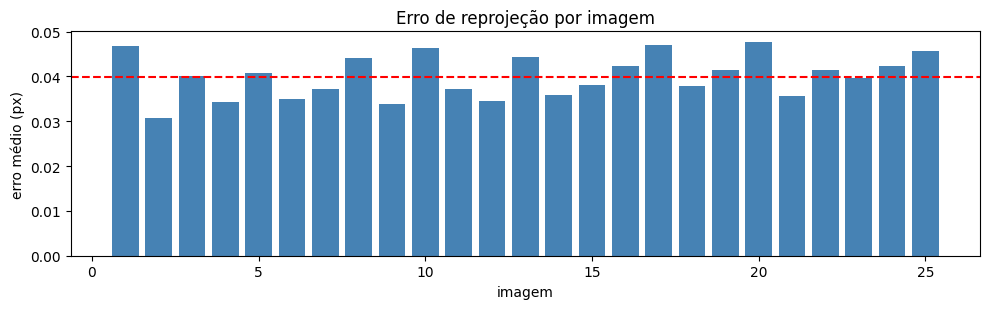

In [8]:
# ===== CALIBRAÇÃO =====
calibration = calibrate_camera(obj_pts, img_pts, detected_image_size)
print(f"erro RMS de reprojeção: {calibration.rms:.4f} px")
print("K =\n", calibration.camera_matrix)
print("distorção [k1 k2 p1 p2 k3] =", calibration.distortion)
print(f"campo de visão: {calibration.fov_x:.1f}° x {calibration.fov_y:.1f}°")
print(f"erro médio por imagem: {calibration.reprojection_errors.mean():.4f} px")

plt.figure(figsize=(10, 3.2))
plt.bar(range(1, len(calibration.reprojection_errors)+1), calibration.reprojection_errors, color="steelblue")
plt.axhline(calibration.reprojection_errors.mean(), color="r", ls="--")
plt.xlabel("imagem")
plt.ylabel("erro médio (px)")
plt.title("Erro de reprojeção por imagem")
plt.tight_layout()
save_figure("erro_por_imagem.png", paths.figures)
plt.show()


In [9]:
# ===== COMPARAÇÃO COM A VERDADE SINTÉTICA =====
resultados = {
    "n_fotos": len(calibration_images),
    "n_usadas": len(used_images),
    "rms": calibration.rms,
    "K": calibration.camera_matrix.tolist(),
    "dist": calibration.distortion.tolist(),
    "fov": [calibration.fov_x, calibration.fov_y],
    "erro_medio": float(calibration.reprojection_errors.mean()),
    "erro_max": float(calibration.reprojection_errors.max()),
    "tam": list(calibration.image_size),
}
compare_with_ground_truth(config, paths, calibration.camera_matrix, calibration.distortion, resultados)


           real   estimado      erro
fx    1400.0000  1399.8744   -0.1256
fy    1395.0000  1394.8143   -0.1857
cx     810.0000   809.9560   -0.0440
cy     590.0000   590.1263    0.1263
k1      -0.2800    -0.2788    0.0012
k2       0.1200     0.1138   -0.0062
p1       0.0010     0.0010   -0.0000
p2      -0.0015    -0.0015   -0.0000
k3      -0.0200    -0.0084    0.0116


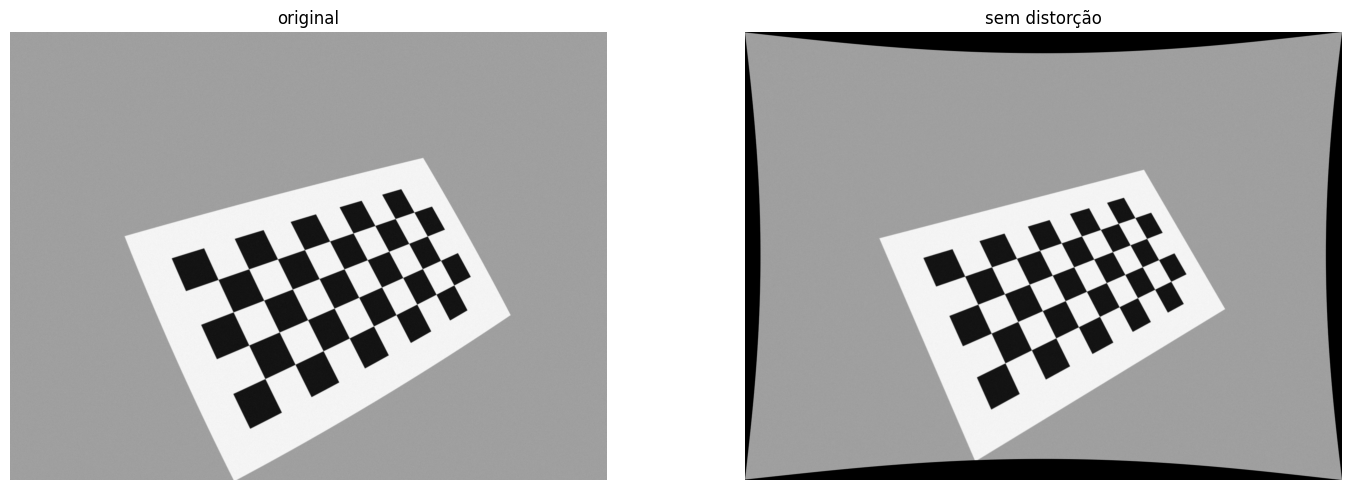

In [10]:
# ===== REMOÇÃO DA DISTORÇÃO =====
undistortion_maps = create_undistortion_maps(
    calibration.camera_matrix,
    calibration.distortion,
    calibration.image_size,
    config,
)
original = load_image(used_images[1])
corrected = undistort_image(original, undistortion_maps)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB)); axes[0].set_title("original"); axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(corrected, cv2.COLOR_BGR2RGB)); axes[1].set_title("sem distorção"); axes[1].axis("off")
plt.tight_layout()
save_figure("remocao_distorcao.png", paths.figures)
plt.show()


## Campo de distorção

A visualização usa a matriz calibrada e os coeficientes de distorção.


In [11]:
# ===== CAMPO DE DISTORÇÃO =====
gx, gy = np.meshgrid(
    np.linspace(0, calibration.image_size[0]-1, 25),
    np.linspace(0, calibration.image_size[1]-1, 19),
)
ideal = np.stack([gx.ravel(), gy.ravel()], 1).astype(np.float32)
raio = cv2.undistortPoints(ideal.reshape(-1,1,2), calibration.camera_matrix, np.zeros(5)).reshape(-1,2)
raio3 = np.hstack([raio, np.ones((len(raio), 1))])
real_px = cv2.projectPoints(raio3, np.zeros(3), np.zeros(3), calibration.camera_matrix, calibration.distortion)[0].reshape(-1,2)
deslocamento = real_px - ideal
print(f"deslocamento máximo: {np.linalg.norm(deslocamento, axis=1).max():.1f} px")


deslocamento máximo: 114.4 px


In [12]:
# ===== EXPERIMENTO 3D -> 2D =====
# O notebook mantém a visualização. Os cálculos reutilizáveis devem ser chamados
# a partir de calibration.camera.
# Código original para conferência manual:
# ids_ext = [0, CANTOS[0]-1, CANTOS[0]*(CANTOS[1]-1), CANTOS[0]*CANTOS[1]-1]
# ids_int = [i for i in range(len(OBJP)) if i not in ids_ext]
# ok, r, t = cv2.solvePnP(OBJP[ids_ext], c[ids_ext], K, dist, flags=cv2.SOLVEPNP_IPPE)
# proj = cv2.projectPoints(OBJP[ids_int], r, t, K, dist)[0].reshape(-1, 2)


In [13]:
# ===== CALIBRAÇÃO ESTÉREO (OPCIONAL) =====
stereo_pairs = pair_stereo_images(paths.stereo_left, paths.stereo_right)
print("pares estéreo:", len(stereo_pairs))
# from calibration.stereo import collect_stereo_results, calibrate_stereo, triangulate_points


pares estéreo: 12


In [14]:
# ===== SALVA TODAS AS FOTOS SEM DISTORÇÃO =====
for path in used_images + test_images:
    corrected = undistort_image(load_image(path), undistortion_maps)
    cv2.imwrite(str(paths.corrected_images / (Path(path).stem + "_corrigida.png")), corrected)
print(len(list(paths.corrected_images.iterdir())), "imagens corrigidas em", paths.corrected_images)


28 imagens corrigidas em data/synthetic/output/corrected_images


In [15]:
# ===== MÉTRICAS E RELATÓRIO =====
# CalibrationResults ainda não expõe std_int; o vetor abaixo é provisório.
std_int = np.zeros(9)
latex_lines = save_calibration_results(calibration, std_int, resultados, paths.metrics)
print_summary(calibration, resultados, latex_lines)
print_output_contents(paths.output)


===== RESUMO =====
fotos: 25/25 | resolução 1600x1200
fx=1399.87 fy=1394.81 cx=809.96 cy=590.13
dist = [-0.27881  0.11381  0.00097 -0.00154 -0.00843]
RMS = 0.0448 px | FOV 59.5° x 46.6°

--- tabelas LaTeX (também em dados/tabelas_latex.txt) ---
$f_x$ (px) & 1399{,}87 & 0{,}00 \\
$f_y$ (px) & 1394{,}81 & 0{,}00 \\
$c_x$ (px) & 809{,}96 & 0{,}00 \\
$c_y$ (px) & 590{,}13 & 0{,}00 \\
$k_1$ & -0{,}2788 & 0{,}0000 \\
$k_2$ & 0{,}1138 & 0{,}0000 \\
$p_1$ & 0{,}0010 & 0{,}0000 \\
$p_2$ & -0{,}0015 & 0{,}0000 \\
$k_3$ & -0{,}0084 & 0{,}0000 \\
RMS (px) & \multicolumn{2}{c}{0{,}045} \\

% experimento 3D -> 2D

===== CONTEÚDO DA PASTA DE SAÍDA =====
output/ (0 arquivos)
   corrected_images/ (28 arquivos)
   figures/ (3 arquivos)
   metrics/ (4 arquivos)


In [16]:
# ===== ZIP OPCIONAL =====
# archive = create_output_archive(paths.base, paths.output, config.colab)
